In [90]:
# =========================
# IMPORTS GENERALES
# IMPORT GENERALI
# =========================

# pandas y numpy se usan para trabajar con datos tabulares
# pandas e numpy si usano per lavorare con dati tabellari
# y realizar operaciones numéricas de forma eficiente.
# e per eseguire operazioni numeriche in modo efficiente.
import pandas as pd
import numpy as np

# matplotlib y seaborn se utilizan para generar gráficas
# matplotlib e seaborn si utilizzano per generare grafici
# que nos ayuden a entender mejor el comportamiento de los datos.
# che ci aiutano a comprendere meglio il comportamento dei dati.
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de scikit-learn para dividir datos,
# Strumenti di scikit-learn per suddividere i dati,
# entrenar árboles de decisión y evaluar resultados.
# addestrare alberi decisionali e valutare i risultati.
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# RandomForestClassifier es un modelo de ensamblado que combina múltiples
# RandomForestClassifier è un modello di ensemble che combina molteplici
# árboles de decisión para obtener una clasificación más estable y robusta.
# alberi decisionali per ottenere una classificazione più stabile e robusta.
from sklearn.ensemble import RandomForestClassifier

# warnings se usa para ocultar avisos que no afectan
# warnings si usa per nascondere avvisi che non influenzano
# al funcionamiento del notebook y así mantenerlo más limpio.
# il funzionamento del notebook e mantenerlo così più pulito.
import warnings
warnings.filterwarnings("ignore")

# Ajustes visuales de pandas para mostrar más columnas y filas
# Impostazioni visive di pandas per mostrare più colonne e righe
# cuando inspeccionamos los datasets.
# quando ispezioniamo i dataset.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Configuración estética general de seaborn para que
# Configurazione estetica generale di seaborn affinché
# las gráficas tengan un formato más profesional.
# i grafici abbiano un aspetto più professionale.
sns.set_theme(style="whitegrid")

# PoC - Detección de anomalías de comportamiento en Login Log y Activity Log

## Objetivo
Construir un sistema de Machine Learning basado en Árboles de Decisión que sea capaz de detectar comportamientos anómalos en el uso de una aplicación tipo gestor de contraseñas.

## Reglas de negocio definidas

### 1. Login Log
- Los usuarios trabajan de lunes a viernes entre las 09:00 y las 18:00.
- Usuario 1 (**Matteo Nicolosi**): logins habituales entre 09:00 y 12:00.
- Usuario 2 (**Diego Scardino**): logins habituales entre 12:00 y 15:00.
- Usuario 3 (**Emilio Sardo**): logins habituales entre 15:00 y 18:00.

### 2. Activity Log
- Las acciones válidas se realizan de lunes a viernes entre las 09:00 y las 18:00.
- Solo se consideran normales acciones sobre `entity_id = 1` (**password**) dentro de los elementos asignados a cada usuario.
- Acciones disponibles:
  - `1000000` → Visualize
  - `1000001` → Create
  - `1000002` → Edit
  - `1000003` → Delete
  - `1000004` → Copy
  - `1000005` → Share

### 3. Objetivos del modelo
- Detectar logins fuera de la franja habitual del usuario.
- Detectar acciones sobre elementos no autorizados para ese usuario.
- Detectar acciones fuera del horario laboral o en días no laborables.

---

# PoC - Rilevamento di anomalie comportamentali nei Login Log e negli Activity Log

## Obiettivo
Costruire un sistema di Machine Learning basato su Alberi di Decisione capace di rilevare comportamenti anomali nell’utilizzo di un’applicazione simile a un gestore di password.

## Regole di business definite

### 1. Login Log
- Gli utenti lavorano dal lunedì al venerdì tra le 09:00 e le 18:00.
- Utente 1 (**Matteo Nicolosi**): login abituali tra le 09:00 e le 12:00.
- Utente 2 (**Diego Scardino**): login abituali tra le 12:00 e le 15:00.
- Utente 3 (**Emilio Sardo**): login abituali tra le 15:00 e le 18:00.

### 2. Activity Log
- Le azioni valide vengono eseguite dal lunedì al venerdì tra le 09:00 e le 18:00.
- Sono considerate normali solo le azioni su `entity_id = 1` (**password**) all’interno degli elementi assegnati a ciascun utente.
- Azioni disponibili:
  - `1000000` → Visualize
  - `1000001` → Create
  - `1000002` → Edit
  - `1000003` → Delete
  - `1000004` → Copy
  - `1000005` → Share

### 3. Obiettivi del modello
- Rilevare login effettuati fuori dalla fascia oraria abituale dell’utente.
- Rilevare azioni su elementi non autorizzati per quello specifico utente.
- Rilevare azioni eseguite fuori dall’orario lavorativo o in giorni non lavorativi.

In [ ]:
# =========================
# CARGA DE DATOS
# CARICAMENTO DEI DATI
# =========================

# Rutas de los archivos CSV.
# Percorsi dei file CSV.
login_path = 'login_log_202604091116.csv'
activity_path = 'activity_log_202604091116.csv'

# Leemos ambos archivos con pandas.
# Leggiamo entrambi i file con pandas.
# Cada CSV se convierte en un DataFrame.
# Ogni CSV viene convertito in un DataFrame.
keyoverLogin = pd.read_csv(login_path)
keyoverActivity = pd.read_csv(activity_path)

# Mostramos el tamaño de cada dataset para comprobar
# Mostriamo la dimensione di ogni dataset per verificare
# que se han cargado correctamente.
# che siano stati caricati correttamente.
print("Dimensioni Login Log:", keyoverLogin.shape)
print("Dimensioni Activity Log:", keyoverActivity.shape)

Dimensioni Login Log: (1318, 6)
Dimensioni Activity Log: (3000, 6)


In [92]:
# Mostramos una vista previa de los datos para entender
# Mostriamo un'anteprima dei dati per capire
# cómo están estructurados los registros de login.
# come sono strutturati i record di login.
print("LOGIN LOG")
display(keyoverLogin.head())

# Mostramos una vista previa del dataset de actividad
# Mostriamo un'anteprima del dataset di attività
# para ver qué información contiene cada acción realizada.
# per vedere quali informazioni contiene ogni azione eseguita.
print("\nACTIVITY LOG")
display(keyoverActivity.head())

LOGIN LOG


,login_log_id,user_id,result,attempt,logged_at,logout_at
0,3,1,True,3,2026-01-01 09:06:55.942,2026-01-01 11:37:30.892
1,4,2,True,1,2026-01-01 12:23:22.204,2026-01-01 14:43:33.309
2,6,3,True,2,2026-01-01 17:40:17.890,2026-01-01 17:45:31.702
3,9,1,True,3,2026-01-02 10:10:32.177,2026-01-02 11:45:44.730
4,10,2,True,1,2026-01-02 12:47:29.386,2026-01-02 14:47:44.837



ACTIVITY LOG


,activity_log_id,user_id,element_id,entity_id,action_id,logged_at
0,1,1,2,1,1000000,2026-01-01 10:31:04.217
1,2,2,3,1,1000004,2026-01-01 14:37:47.860
2,3,3,6,1,1000005,2026-01-01 17:44:36.455
3,4,1,1,1,1000000,2026-01-02 10:14:36.855
4,5,1,2,1,1000000,2026-01-02 10:15:31.904


In [93]:
# info() nos permite revisar:
# info() ci permette di controllare:
# - número de filas
# - numero di righe
# - número de columnas
# - numero di colonne
# - tipo de dato de cada columna
# - tipo di dato di ogni colonna
# - cuántos valores no nulos hay
# - quanti valori non nulli ci sono
# Esto ayuda a detectar problemas antes del análisis.
# Questo aiuta a rilevare problemi prima dell'analisi.
print("======== LOGIN LOG INFO ========")
print(keyoverLogin.info())

print("\n======== ACTIVITY LOG INFO ========")
print(keyoverActivity.info())

======== LOGIN LOG INFO ========
<class 'pandas.DataFrame'>
RangeIndex: 1318 entries, 0 to 1317
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   login_log_id  1318 non-null   int64
 1   user_id       1318 non-null   int64
 2   result        1318 non-null   bool 
 3   attempt       1318 non-null   int64
 4   logged_at     1318 non-null   str  
 5   logout_at     1318 non-null   str  
dtypes: bool(1), int64(3), str(2)
memory usage: 52.9 KB
None

======== ACTIVITY LOG INFO ========
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   activity_log_id  3000 non-null   int64
 1   user_id          3000 non-null   int64
 2   element_id       3000 non-null   int64
 3   entity_id        3000 non-null   int64
 4   action_id        3000 non-null   int64
 5   logged_at        3000 non-null   str  

In [94]:
# Comprobamos si hay valores nulos en el dataset de login.
# Controlliamo se ci sono valori nulli nel dataset di login.
# Esto es importante porque los modelos no suelen trabajar bien con nulos.
# Questo è importante perché i modelli di solito non lavorano bene con valori nulli.
print("VALORI NULLI LOGIN LOG")
display(keyoverLogin.isnull().sum())

# Comprobamos si hay valores nulos en el dataset de actividad.
# Controlliamo se ci sono valori nulli nel dataset di attività.
print("\nVALORI NULLI ACTIVITY LOG")
display(keyoverActivity.isnull().sum())

# También revisamos si hay filas duplicadas.
# Controlliamo anche se ci sono righe duplicate.
# Los duplicados pueden introducir sesgos en el entrenamiento.
# I duplicati possono introdurre bias nell'addestramento.
print("\nDUPLICATI LOGIN LOG:", keyoverLogin.duplicated().sum())
print("DUPLICATI ACTIVITY LOG:", keyoverActivity.duplicated().sum())

VALORI NULLI LOGIN LOG


login_log_id    0
user_id         0
result          0
attempt         0
logged_at       0
logout_at       0
dtype: int64


VALORI NULLI ACTIVITY LOG


activity_log_id    0
user_id            0
element_id         0
entity_id          0
action_id          0
logged_at          0
dtype: int64


DUPLICATI LOGIN LOG: 0
DUPLICATI ACTIVITY LOG: 0


In [95]:
# =========================
# CONVERSIÓN DE FECHAS
# CONVERSIONE DELLE DATE
# =========================

# Convertimos las columnas temporales de login a formato datetime.
# Convertiamo le colonne temporali di login nel formato datetime.
# Esto permitirá extraer información temporal de forma sencilla.
# Questo permetterà di estrarre informazioni temporali in modo semplice.
keyoverLogin["logged_at"] = pd.to_datetime(keyoverLogin["logged_at"], errors="coerce")
keyoverLogin["logout_at"] = pd.to_datetime(keyoverLogin["logout_at"], errors="coerce")

# Hacemos lo mismo con la columna temporal del dataset de actividad.
# Facciamo lo stesso con la colonna temporale del dataset di attività.
keyoverActivity["logged_at"] = pd.to_datetime(keyoverActivity["logged_at"], errors="coerce")

# Mensaje de confirmación.
# Messaggio di conferma.
print("Conversione delle date completata correttamente.")

Conversione delle date completata correttamente.


In [96]:
# =========================
# DICCIONARIOS DE NEGOCIO
# DIZIONARI DI BUSINESS
# =========================

# Relación entre user_id y nombre real del usuario.
# Relazione tra user_id e nome reale dell'utente.
# Esto mejora la legibilidad del análisis y las tablas finales.
# Questo migliora la leggibilità dell'analisi e delle tabelle finali.
user_names = {
    1: "Matteo Nicolosi",
    2: "Diego Scardino",
    3: "Emilio Sardo"
}

# Relación entre action_id y nombre descriptivo de la acción.
# Relazione tra action_id e nome descrittivo dell'azione.
# También sirve para que las gráficas y resultados sean más comprensibles.
# Serve anche a rendere i grafici e i risultati più comprensibili.
action_names = {
    1000000: "Visualize",
    1000001: "Create",
    1000002: "Edit",
    1000003: "Delete",
    1000004: "Copy",
    1000005: "Share"
}

# Ventanas horarias habituales de login por usuario.
# Fasce orarie abituali di login per utente.
# Estas reglas se usarán para detectar accesos fuera de lo normal.
# Queste regole saranno utilizzate per rilevare accessi fuori dalla norma.
login_windows = {
    1: (9, 12),   # Matteo
    2: (12, 15),  # Diego
    3: (15, 18)   # Emilio
}

# Elementos permitidos por usuario en el Activity Log.
# Elementi consentiti per utente nell'Activity Log.
# Si un usuario actúa sobre un element_id no autorizado,
# Se un utente agisce su un element_id non autorizzato,
# la acción se considerará anómala.
# l'azione sarà considerata anomala.
allowed_elements = {
    1: [1, 2],          # Matteo -> FVG, AMCO
    2: [3],             # Diego -> VETTING
    3: [4, 1, 5, 6]     # Emilio -> RHODENSE, FVG, PAPARDO, PULEJO
}

# Entity válida según el enunciado del PoC.
# Entity valida secondo il testo del PoC.
# Se asume que las acciones normales son sobre entity_id = 1 (password).
# Si assume che le azioni normali siano su entity_id = 1 (password).
allowed_entity_id = 1

# Acciones consideradas normales en el flujo estándar descrito.
# Azioni considerate normali nel flusso standard descritto.
# Si negocio luego confirma más acciones como normales,
# Se in seguito il business conferma altre azioni come normali,
# bastará con ampliar esta lista.
# basterà ampliare questa lista.
allowed_actions = [1000000, 1000004, 1000005]   # Visualize, Copy, Share

print("Dizionari caricati.")

Dizionari caricati.


In [97]:
# =========================
# FEATURE ENGINEERING LOGIN
# FEATURE ENGINEERING LOGIN
# =========================

# Creamos una copia para no modificar el dataset original.
# Creiamo una copia per non modificare il dataset originale.
login_df = keyoverLogin.copy()

# Añadimos el nombre del usuario usando el diccionario definido antes.
# Aggiungiamo il nome dell'utente usando il dizionario definito in precedenza.
login_df["user_name"] = login_df["user_id"].map(user_names)

# Extraemos la hora y el minuto del momento de login.
# Estraiamo l'ora e il minuto del momento del login.
# Esto es clave para detectar accesos fuera de la franja habitual.
# Questo è fondamentale per rilevare accessi fuori dalla fascia abituale.
login_df["hour"] = login_df["logged_at"].dt.hour
login_df["minute"] = login_df["logged_at"].dt.minute

# Extraemos el día de la semana:
# Estraiamo il giorno della settimana:
# lunes = 0, martes = 1, ..., domingo = 6
# lunedì = 0, martedì = 1, ..., domenica = 6
# Esto permitirá detectar accesos en fin de semana.
# Questo permetterà di rilevare accessi nel fine settimana.
login_df["day_of_week"] = login_df["logged_at"].dt.dayofweek

# Guardamos también solo la fecha por si queremos hacer agregados diarios.
# Salviamo anche solo la data nel caso in cui vogliamo fare aggregazioni giornaliere.
login_df["date"] = login_df["logged_at"].dt.date

# Calculamos la duración de la sesión en minutos.
# Calcoliamo la durata della sessione in minuti.
# Esto puede ayudar a detectar comportamientos atípicos.
# Questo può aiutare a rilevare comportamenti atipici.
login_df["session_duration_min"] = (
    (login_df["logout_at"] - login_df["logged_at"]).dt.total_seconds() / 60
)

# Flag para indicar si el acceso fue entre lunes y viernes.
# Flag per indicare se l'accesso è avvenuto tra lunedì e venerdì.
login_df["is_weekday"] = login_df["day_of_week"].between(0, 4).astype(int)

# Flag para indicar si el acceso fue en horario laboral general.
# Flag per indicare se l'accesso è avvenuto in orario lavorativo generale.
# Se usa una ventana amplia de 09:00 a 17:59.
# Si utilizza una fascia ampia dalle 09:00 alle 17:59.
login_df["is_working_hours"] = login_df["hour"].between(9, 17).astype(int)

# Mostramos una vista previa del dataset enriquecido.
# Mostriamo un'anteprima del dataset arricchito.
display(login_df.head())

,login_log_id,user_id,result,attempt,logged_at,logout_at,user_name,hour,minute,day_of_week,date,session_duration_min,is_weekday,is_working_hours
0,3,1,True,3,2026-01-01 09:06:55.942,2026-01-01 11:37:30.892,Matteo Nicolosi,9,6,3,2026-01-01,150.582500,1,1
1,4,2,True,1,2026-01-01 12:23:22.204,2026-01-01 14:43:33.309,Diego Scardino,12,23,3,2026-01-01,140.185083,1,1
2,6,3,True,2,2026-01-01 17:40:17.890,2026-01-01 17:45:31.702,Emilio Sardo,17,40,3,2026-01-01,5.230200,1,1
3,9,1,True,3,2026-01-02 10:10:32.177,2026-01-02 11:45:44.730,Matteo Nicolosi,10,10,4,2026-01-02,95.209217,1,1
4,10,2,True,1,2026-01-02 12:47:29.386,2026-01-02 14:47:44.837,Diego Scardino,12,47,4,2026-01-02,120.257517,1,1


In [98]:
# =========================
# FEATURE ENGINEERING ACTIVITY
# FEATURE ENGINEERING ACTIVITY
# =========================

# Creamos una copia para trabajar con seguridad.
# Creiamo una copia per lavorare in sicurezza.
activity_df = keyoverActivity.copy()

# Añadimos el nombre del usuario y el nombre descriptivo de la acción.
# Aggiungiamo il nome dell'utente e il nome descrittivo dell'azione.
# Esto mejora la interpretabilidad del análisis.
# Questo migliora l'interpretabilità dell'analisi.
activity_df["user_name"] = activity_df["user_id"].map(user_names)
activity_df["action_name"] = activity_df["action_id"].map(action_names)

# Extraemos hora y minuto de cada actividad.
# Estraiamo l'ora e il minuto di ogni attività.
# Estas variables permitirán evaluar si la actividad ocurre
# Queste variabili permetteranno di valutare se l'attività avviene
# dentro del horario esperado del usuario.
# all'interno dell'orario previsto per l'utente.
activity_df["hour"] = activity_df["logged_at"].dt.hour
activity_df["minute"] = activity_df["logged_at"].dt.minute

# Extraemos también el día de la semana y la fecha.
# Estraiamo anche il giorno della settimana e la data.
activity_df["day_of_week"] = activity_df["logged_at"].dt.dayofweek
activity_df["date"] = activity_df["logged_at"].dt.date

# Flags auxiliares para saber si la actividad ocurrió
# Flag ausiliari per sapere se l'attività è avvenuta
# en día laborable y dentro del horario general de trabajo.
# in un giorno lavorativo e all'interno dell'orario generale di lavoro.
activity_df["is_weekday"] = activity_df["day_of_week"].between(0, 4).astype(int)
activity_df["is_working_hours"] = activity_df["hour"].between(9, 17).astype(int)

# Mostramos resultado intermedio.
# Mostriamo il risultato intermedio.
display(activity_df.head())

,activity_log_id,user_id,element_id,entity_id,action_id,logged_at,user_name,action_name,hour,minute,day_of_week,date,is_weekday,is_working_hours
0,1,1,2,1,1000000,2026-01-01 10:31:04.217,Matteo Nicolosi,Visualize,10,31,3,2026-01-01,1,1
1,2,2,3,1,1000004,2026-01-01 14:37:47.860,Diego Scardino,Copy,14,37,3,2026-01-01,1,1
2,3,3,6,1,1000005,2026-01-01 17:44:36.455,Emilio Sardo,Share,17,44,3,2026-01-01,1,1
3,4,1,1,1,1000000,2026-01-02 10:14:36.855,Matteo Nicolosi,Visualize,10,14,4,2026-01-02,1,1
4,5,1,2,1,1000000,2026-01-02 10:15:31.904,Matteo Nicolosi,Visualize,10,15,4,2026-01-02,1,1


In [99]:
# =========================
# ETIQUETADO DE ANOMALÍAS LOGIN
# ETICHETTATURA DELLE ANOMALIE LOGIN
# =========================

# Definimos una función que revisa cada fila del dataset
# Definiamo una funzione che analizza ogni riga del dataset
# y devuelve 1 si el login es anómalo, o 0 si es normal.
# e restituisce 1 se il login è anomalo, oppure 0 se è normale.
def login_is_anomalous(row):
    user_id = row["user_id"]
    hour = row["hour"]
    day_of_week = row["day_of_week"]

    # Regla 1:
    # Regola 1:
    # El acceso debe producirse de lunes a viernes.
    # L'accesso deve avvenire dal lunedì al venerdì.
    # Si ocurre en sábado o domingo, se marca como anómalo.
    # Se avviene di sabato o domenica, viene contrassegnato come anomalo.
    if day_of_week not in [0, 1, 2, 3, 4]:
        return 1

    # Regla 2:
    # Regola 2:
    # El acceso debe estar dentro de la ventana habitual del usuario.
    # L'accesso deve rientrare nella fascia oraria abituale dell'utente.
    if user_id in login_windows:
        start_hour, end_hour = login_windows[user_id]
        if not (start_hour <= hour < end_hour):
            return 1

    # Si no incumple ninguna regla, se considera normal.
    # Se non viola nessuna regola, viene considerato normale.
    return 0

# Aplicamos la función a cada fila del dataset
# Applichiamo la funzione a ogni riga del dataset
# para construir la variable objetivo del modelo.
# per costruire la variabile target del modello.
login_df["anomaly"] = login_df.apply(login_is_anomalous, axis=1)

# Mostramos algunas filas para comprobar el resultado.
# Mostriamo alcune righe per verificare il risultato.
display(login_df.head())

# Contamos cuántos casos se han etiquetado como anomalías.
# Contiamo quanti casi sono stati etichettati come anomalie.
print("Numero di anomalie nel login:", login_df["anomaly"].sum())

,login_log_id,user_id,result,attempt,logged_at,logout_at,user_name,hour,minute,day_of_week,date,session_duration_min,is_weekday,is_working_hours,anomaly
0,3,1,True,3,2026-01-01 09:06:55.942,2026-01-01 11:37:30.892,Matteo Nicolosi,9,6,3,2026-01-01,150.582500,1,1,0
1,4,2,True,1,2026-01-01 12:23:22.204,2026-01-01 14:43:33.309,Diego Scardino,12,23,3,2026-01-01,140.185083,1,1,0
2,6,3,True,2,2026-01-01 17:40:17.890,2026-01-01 17:45:31.702,Emilio Sardo,17,40,3,2026-01-01,5.230200,1,1,0
3,9,1,True,3,2026-01-02 10:10:32.177,2026-01-02 11:45:44.730,Matteo Nicolosi,10,10,4,2026-01-02,95.209217,1,1,0
4,10,2,True,1,2026-01-02 12:47:29.386,2026-01-02 14:47:44.837,Diego Scardino,12,47,4,2026-01-02,120.257517,1,1,0


Numero di anomalie nel login: 0


In [100]:
# =========================
# ETIQUETADO DE ANOMALÍAS ACTIVITY
# ETICHETTATURA DELLE ANOMALIE ACTIVITY
# =========================

# Esta función evalúa si una actividad es normal o anómala
# Questa funzione valuta se un'attività è normale o anomala
# en función de las reglas de negocio proporcionadas.
# in base alle regole di business fornite.
def activity_is_anomalous(row):
    user_id = row["user_id"]
    element_id = row["element_id"]
    entity_id = row["entity_id"]
    action_id = row["action_id"]
    hour = row["hour"]
    day_of_week = row["day_of_week"]

    # Regla 1:
    # Regola 1:
    # La actividad debe ocurrir de lunes a viernes.
    # L'attività deve avvenire dal lunedì al venerdì.
    if day_of_week not in [0, 1, 2, 3, 4]:
        return 1

    # Regla 2:
    # Regola 2:
    # La actividad debe darse dentro del horario laboral general.
    # L'attività deve svolgersi all'interno dell'orario lavorativo generale.
    if not (9 <= hour < 18):
        return 1

    # Regla 3:
    # Regola 3:
    # Solo se consideran normales las actividades sobre entity_id = 1.
    # Solo le attività su entity_id = 1 sono considerate normali.
    if entity_id != allowed_entity_id:
        return 1

    # Regla 4:
    # Regola 4:
    # El flujo estándar contempla Visualize, Copy y Share.
    # Il flusso standard prevede Visualize, Copy e Share.
    # Otras acciones se marcan como anómalas para esta PoC.
    # Le altre azioni vengono contrassegnate come anomale per questa PoC.
    if action_id not in allowed_actions:
        return 1

    # Regla 5:
    # Regola 5:
    # Cada usuario solo debe operar sobre sus elementos permitidos.
    # Ogni utente deve operare solo sui propri elementi consentiti.
    if user_id in allowed_elements:
        if element_id not in allowed_elements[user_id]:
            return 1

    # Regla 6:
    # Regola 6:
    # Además, la actividad debe estar en la franja horaria
    # Inoltre, l'attività deve rientrare nella fascia oraria
    # habitual asociada a ese usuario.
    # abituale associata a quell'utente.
    if user_id in login_windows:
        start_hour, end_hour = login_windows[user_id]
        if not (start_hour <= hour < end_hour):
            return 1

    # Si no se incumple ninguna regla, se considera normal.
    # Se non viene violata nessuna regola, l'attività viene considerata normale.
    return 0

# Creamos la columna objetivo del modelo de actividad.
# Creiamo la colonna target del modello di attività.
activity_df["anomaly"] = activity_df.apply(activity_is_anomalous, axis=1)

# Comprobamos visualmente el resultado.
# Verifichiamo visivamente il risultato.
display(activity_df.head())

# Número total de anomalías detectadas según reglas.
# Numero totale di anomalie rilevate secondo le regole.
print("Numero di anomalie in activity:", activity_df["anomaly"].sum())

,activity_log_id,user_id,element_id,entity_id,action_id,logged_at,user_name,action_name,hour,minute,day_of_week,date,is_weekday,is_working_hours,anomaly
0,1,1,2,1,1000000,2026-01-01 10:31:04.217,Matteo Nicolosi,Visualize,10,31,3,2026-01-01,1,1,0
1,2,2,3,1,1000004,2026-01-01 14:37:47.860,Diego Scardino,Copy,14,37,3,2026-01-01,1,1,0
2,3,3,6,1,1000005,2026-01-01 17:44:36.455,Emilio Sardo,Share,17,44,3,2026-01-01,1,1,0
3,4,1,1,1,1000000,2026-01-02 10:14:36.855,Matteo Nicolosi,Visualize,10,14,4,2026-01-02,1,1,0
4,5,1,2,1,1000000,2026-01-02 10:15:31.904,Matteo Nicolosi,Visualize,10,15,4,2026-01-02,1,1,0


Numero di anomalie in activity: 37


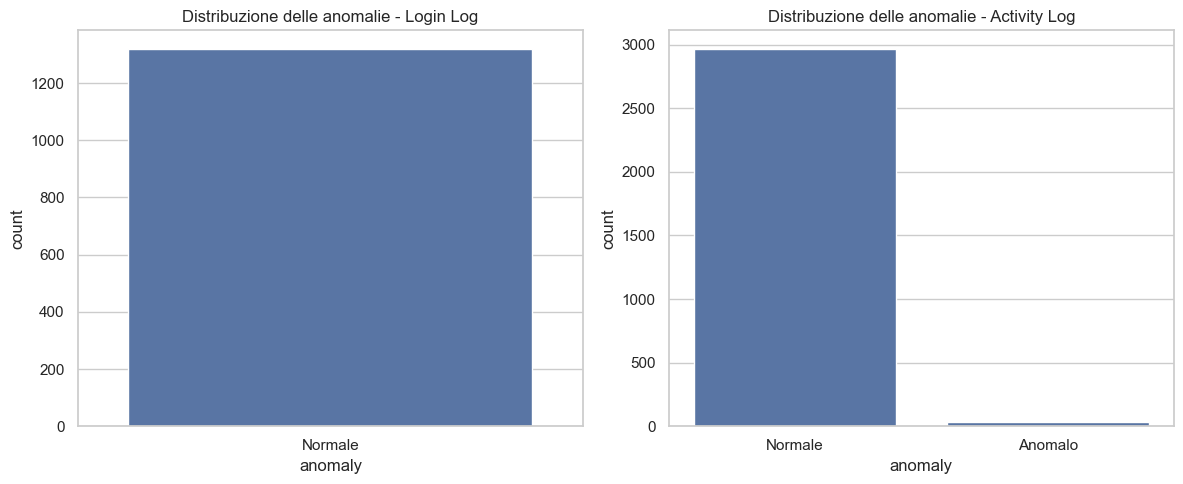

In [101]:
# Representamos visualmente cuántos casos normales y anómalos
# Rappresentiamo visivamente quanti casi normali e anomali
# hay en Login Log y Activity Log.
# ci sono in Login Log e Activity Log.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras para anomalías en login.
# Grafico a barre per le anomalie nel login.
sns.countplot(data=login_df, x="anomaly", ax=axes[0])
axes[0].set_title("Distribuzione delle anomalie - Login Log")
axes[0].set_xticklabels(["Normale", "Anomalo"])

# Gráfico de barras para anomalías en actividad.
# Grafico a barre per le anomalie nell'attività.
sns.countplot(data=activity_df, x="anomaly", ax=axes[1])
axes[1].set_title("Distribuzione delle anomalie - Activity Log")
axes[1].set_xticklabels(["Normale", "Anomalo"])

plt.tight_layout()
plt.show()

Record per utente nel Login Log


user_name
Matteo Nicolosi    440
Diego Scardino     439
Emilio Sardo       439
Name: count, dtype: int64

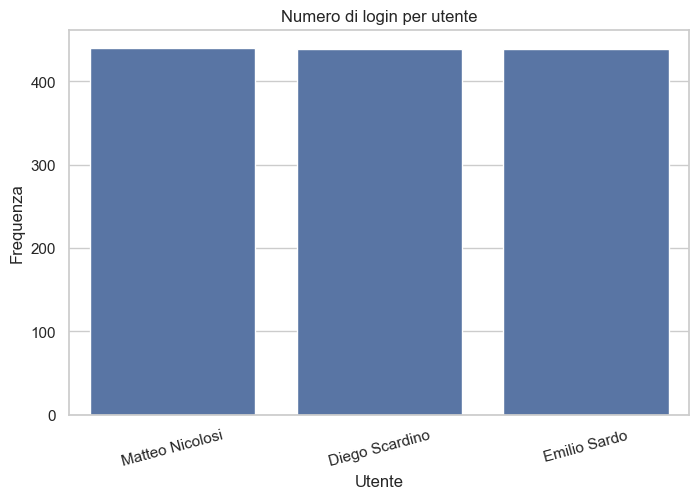

In [102]:
# Analizamos cuántos registros de login tiene cada usuario.
# Analizziamo quanti record di login ha ogni utente.
# Esto permite comprobar si todos los usuarios tienen
# Questo permette di verificare se tutti gli utenti hanno
# suficiente representación en el dataset.
# una rappresentazione sufficiente nel dataset.
print("Record per utente nel Login Log")
display(login_df["user_name"].value_counts())

# Visualización gráfica del número de logins por usuario.
# Visualizzazione grafica del numero di login per utente.
plt.figure(figsize=(8, 5))
sns.countplot(data=login_df, x="user_name")
plt.title("Numero di login per utente")
plt.xlabel("Utente")
plt.ylabel("Frequenza")
plt.xticks(rotation=15)
plt.show()

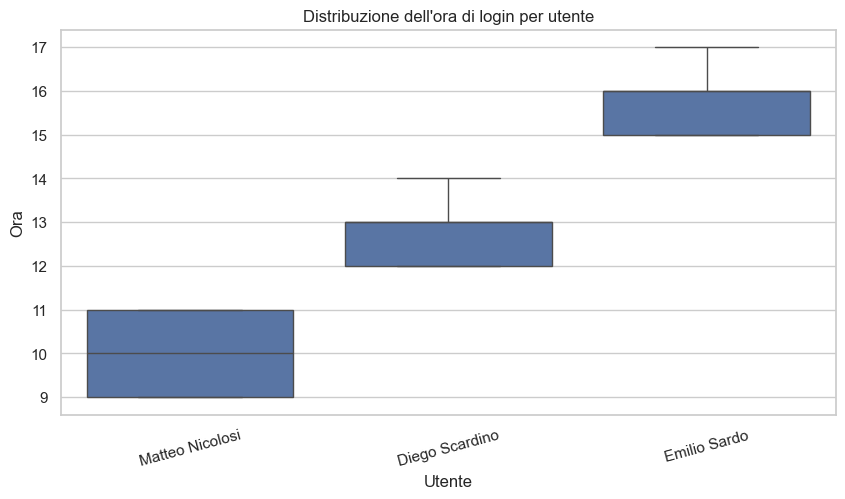

In [103]:
# El boxplot nos permite ver la dispersión de la hora de login
# Il boxplot ci permette di vedere la dispersione dell'ora di login
# para cada usuario y detectar visualmente posibles valores atípicos.
# per ogni utente e di rilevare visivamente possibili valori anomali.
plt.figure(figsize=(10, 5))
sns.boxplot(data=login_df, x="user_name", y="hour")
plt.title("Distribuzione dell'ora di login per utente")
plt.xlabel("Utente")
plt.ylabel("Ora")
plt.xticks(rotation=15)
plt.show()

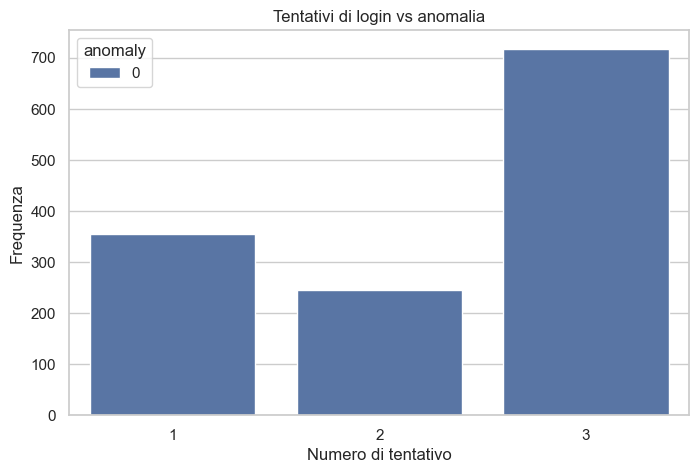

In [104]:
# Observamos cuántos logins se realizan al primer intento,
# Osserviamo quanti login vengono effettuati al primo tentativo,
# segundo intento, etc., y si existe relación con la anomalía.
# al secondo tentativo, ecc., e se esiste una relazione con l'anomalia.
plt.figure(figsize=(8, 5))
sns.countplot(data=login_df, x="attempt", hue="anomaly")
plt.title("Tentativi di login vs anomalia")
plt.xlabel("Numero di tentativo")
plt.ylabel("Frequenza")
plt.show()

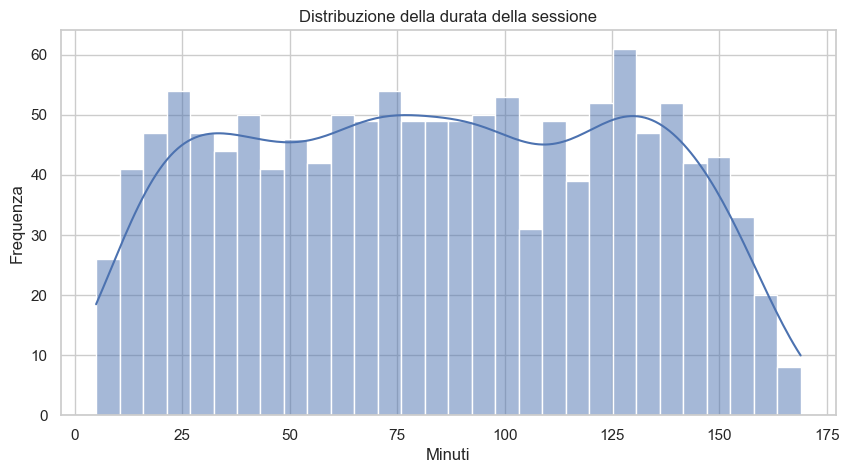

In [105]:
# Histograma de la duración de las sesiones de login.
# Istogramma della durata delle sessioni di login.
# Se añade también una curva KDE para visualizar mejor la densidad.
# Si aggiunge anche una curva KDE per visualizzare meglio la densità.
plt.figure(figsize=(10, 5))
sns.histplot(login_df["session_duration_min"].dropna(), bins=30, kde=True)
plt.title("Distribuzione della durata della sessione")
plt.xlabel("Minuti")
plt.ylabel("Frequenza")
plt.show()

Azioni per utente


user_name        action_name
Diego Scardino   Copy           341
                 Share          313
                 Visualize      302
                 Edit            14
                 Delete           1
Emilio Sardo     Share          340
                 Copy           340
                 Visualize      339
                 Edit             6
Matteo Nicolosi  Share          347
                 Copy           330
                 Visualize      311
                 Edit            16
Name: count, dtype: int64

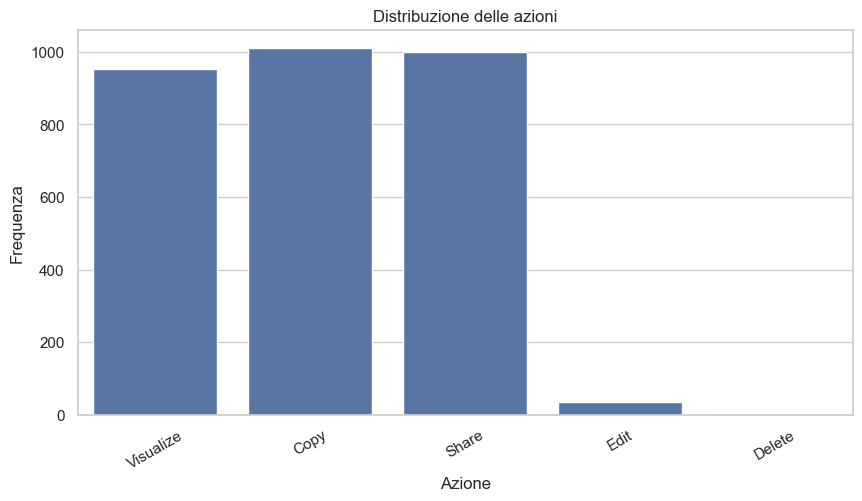

In [106]:
# Mostramos un resumen de cuántas veces realiza cada usuario
# Mostriamo un riepilogo di quante volte ogni utente esegue
# cada tipo de acción.
# ogni tipo di azione.
print("Azioni per utente")
display(activity_df.groupby("user_name")["action_name"].value_counts())

# Gráfico de la distribución global de acciones.
# Grafico della distribuzione globale delle azioni.
plt.figure(figsize=(10, 5))
sns.countplot(data=activity_df, x="action_name")
plt.title("Distribuzione delle azioni")
plt.xlabel("Azione")
plt.ylabel("Frequenza")
plt.xticks(rotation=30)
plt.show()

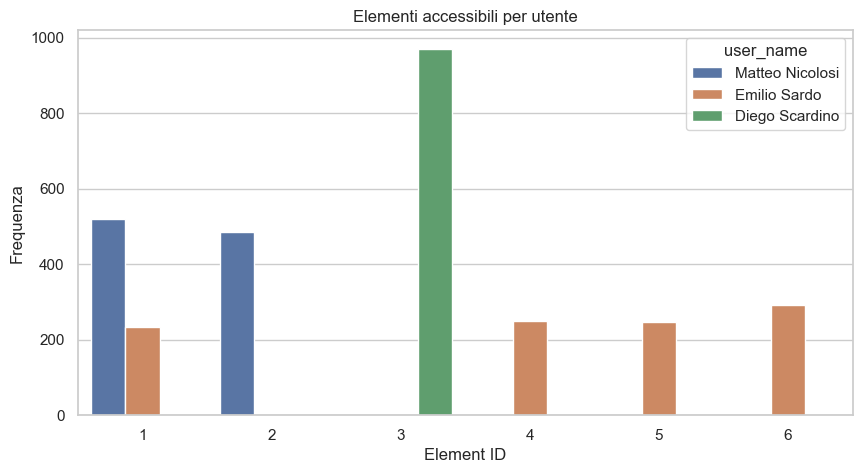

In [107]:
# Este gráfico permite ver qué element_id utiliza cada usuario.
# Questo grafico permette di vedere quale element_id utilizza ogni utente.
# Es útil para detectar visualmente accesos fuera del conjunto esperado.
# È utile per rilevare visivamente accessi al di fuori dell'insieme previsto.
plt.figure(figsize=(10, 5))
sns.countplot(data=activity_df, x="element_id", hue="user_name")
plt.title("Elementi accessibili per utente")
plt.xlabel("Element ID")
plt.ylabel("Frequenza")
plt.show()

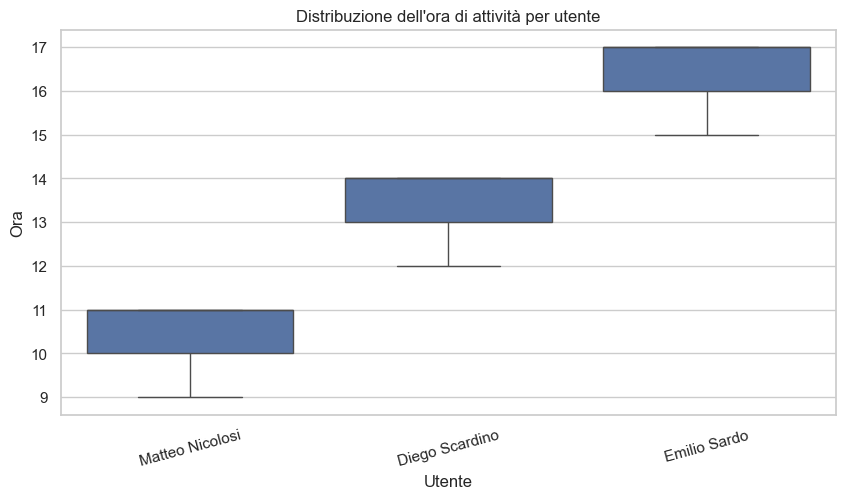

In [108]:
# Al igual que en login, usamos un boxplot para ver
# Come nel login, utilizziamo un boxplot per vedere
# la distribución horaria de las actividades por usuario.
# la distribuzione oraria delle attività per utente.
plt.figure(figsize=(10, 5))
sns.boxplot(data=activity_df, x="user_name", y="hour")
plt.title("Distribuzione dell'ora di attività per utente")
plt.xlabel("Utente")
plt.ylabel("Ora")
plt.xticks(rotation=15)
plt.show()

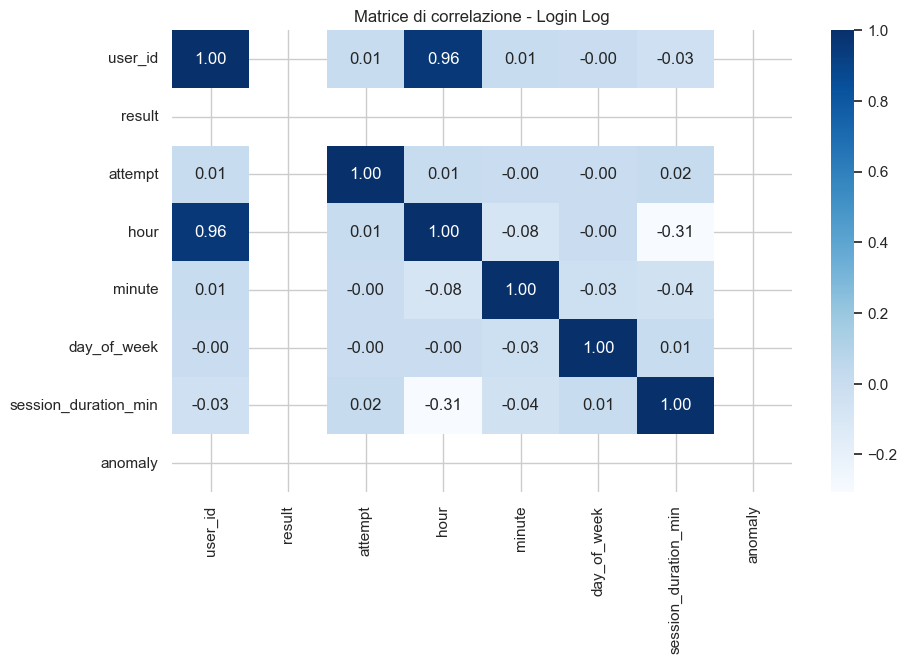

In [109]:
# Seleccionamos las variables numéricas más relevantes del dataset de login.
# Selezioniamo le variabili numeriche più rilevanti del dataset di login.
login_corr_cols = ["user_id", "result", "attempt", "hour", "minute", "day_of_week", "session_duration_min", "anomaly"]

# Heatmap de correlación.
# Heatmap di correlazione.
# No implica causalidad, pero sí ayuda a explorar relaciones.
# Non implica causalità, ma aiuta comunque a esplorare le relazioni.
plt.figure(figsize=(10, 6))
sns.heatmap(login_df[login_corr_cols].corr(numeric_only=True), annot=True, cmap="Blues", fmt=".2f")
plt.title("Matrice di correlazione - Login Log")
plt.show()

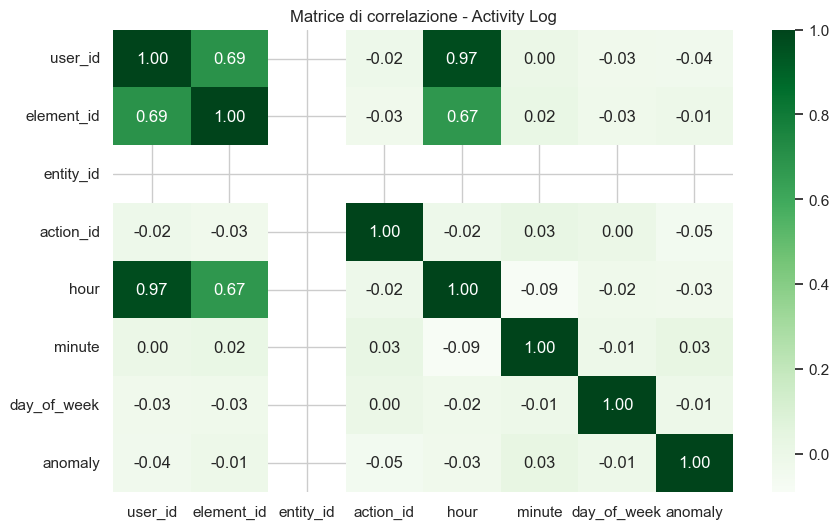

In [110]:
# Variables numéricas del dataset de actividad.
# Variabili numeriche del dataset di attività.
activity_corr_cols = ["user_id", "element_id", "entity_id", "action_id", "hour", "minute", "day_of_week", "anomaly"]

# Calculamos y representamos la matriz de correlación.
# Calcoliamo e rappresentiamo la matrice di correlazione.
plt.figure(figsize=(10, 6))
sns.heatmap(activity_df[activity_corr_cols].corr(numeric_only=True), annot=True, cmap="Greens", fmt=".2f")
plt.title("Matrice di correlazione - Activity Log")
plt.show()

In [111]:
# =========================
# PREPARACIÓN MODELO LOGIN
# PREPARAZIONE MODELLO LOGIN
# =========================

# Creamos una copia específica para modelado.
# Creiamo una copia specifica per la modellazione.
login_model_df = login_df.copy()

# Convertimos la variable booleana result a formato entero
# Convertiamo la variabile booleana result in formato intero
# para que el modelo la trate como variable numérica.
# affinché il modello la tratti come variabile numerica.
login_model_df["result"] = login_model_df["result"].astype(int)

# Seleccionamos las variables de entrada del modelo.
# Selezioniamo le variabili di input del modello.
# Elegimos variables que describen quién accede, cuándo y cómo.
# Scegliamo variabili che descrivono chi accede, quando e come.
features_login = ["user_id", "result", "attempt", "hour", "minute", "day_of_week", "session_duration_min"]
target_login = "anomaly"

# X contiene las variables predictoras.
# X contiene le variabili predittive.
# y contiene la etiqueta objetivo.
# y contiene l'etichetta target.
X_login = login_model_df[features_login].copy()
y_login = login_model_df[target_login].copy()

# Si hubiese nulos en la duración, los rellenamos con 0.
# Se ci fossero valori nulli nella durata, li riempiamo con 0.
# Esto evita errores durante el entrenamiento.
# Questo evita errori durante l'addestramento.
X_login["session_duration_min"] = X_login["session_duration_min"].fillna(0)

# Dividimos los datos en entrenamiento y test.
# Suddividiamo i dati in training e test.
# stratify=y_login ayuda a mantener la proporción de clases.
# stratify=y_login aiuta a mantenere la proporzione delle classi.
Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_login, y_login, test_size=0.2, random_state=42, stratify=y_login
)

print("Training Login:", Xl_train.shape)
print("Test Login:", Xl_test.shape)

Training Login: (1054, 7)
Test Login: (264, 7)


In [112]:
# =========================
# MODELO LOGIN
# MODELLO LOGIN
# =========================

# Creamos el clasificador de árbol de decisión.
# Creiamo il classificatore ad albero decisionale.
# max_depth, min_samples_split y min_samples_leaf ayudan
# max_depth, min_samples_split e min_samples_leaf aiutano
# a evitar sobreajuste y a hacer el árbol más estable.
# a evitare l'overfitting e a rendere l'albero più stabile.
login_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Entrenamos el modelo con los datos de entrenamiento.
# Addestriamo il modello con i dati di training.
login_tree.fit(Xl_train, yl_train)

print("Modello di Login addestrato correttamente.")

Modello di Login addestrato correttamente.


In [113]:
# Generamos predicciones sobre el conjunto de test,
# Generiamo predizioni sul set di test,
# es decir, sobre datos no vistos durante el entrenamiento.
# cioè su dati non visti durante l'addestramento.
yl_pred = login_tree.predict(Xl_test)

# Accuracy global del modelo.
# Accuracy globale del modello.
print("Accuracy Login:", accuracy_score(yl_test, yl_pred))

# El classification report ofrece precisión, recall y f1-score.
# Il classification report fornisce precision, recall e f1-score.
# Estas métricas son más informativas que la accuracy,
# Queste metriche sono più informative dell'accuracy,
# especialmente si hay desbalance de clases.
# soprattutto se c'è uno sbilanciamento tra le classi.
print("\nClassification Report - Login")
print(classification_report(yl_test, yl_pred))

Accuracy Login: 1.0

Classification Report - Login
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       264

    accuracy                           1.00       264
   macro avg       1.00      1.00      1.00       264
weighted avg       1.00      1.00      1.00       264



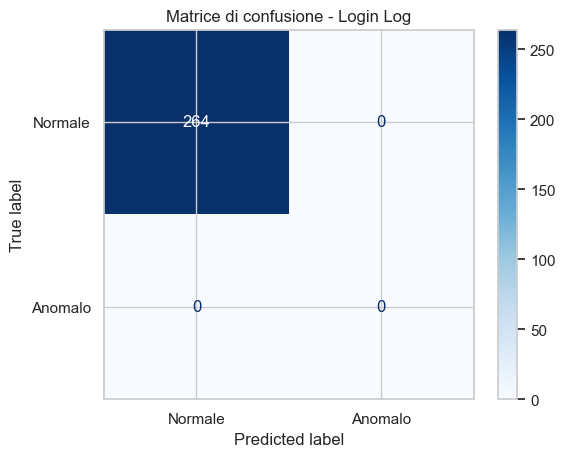

In [114]:
# La matriz de confusión muestra:
# La matrice di confusione mostra:
# - verdaderos normales
# - veri normali
# - falsos positivos
# - falsi positivi
# - falsos negativos
# - falsi negativi
# - verdaderos anómalos
# - veri anomali

cm_login = confusion_matrix(yl_test, yl_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_login,
    display_labels=["Normale", "Anomalo"]
)

disp.plot(cmap="Blues")
plt.title("Matrice di confusione - Login Log")
plt.show()

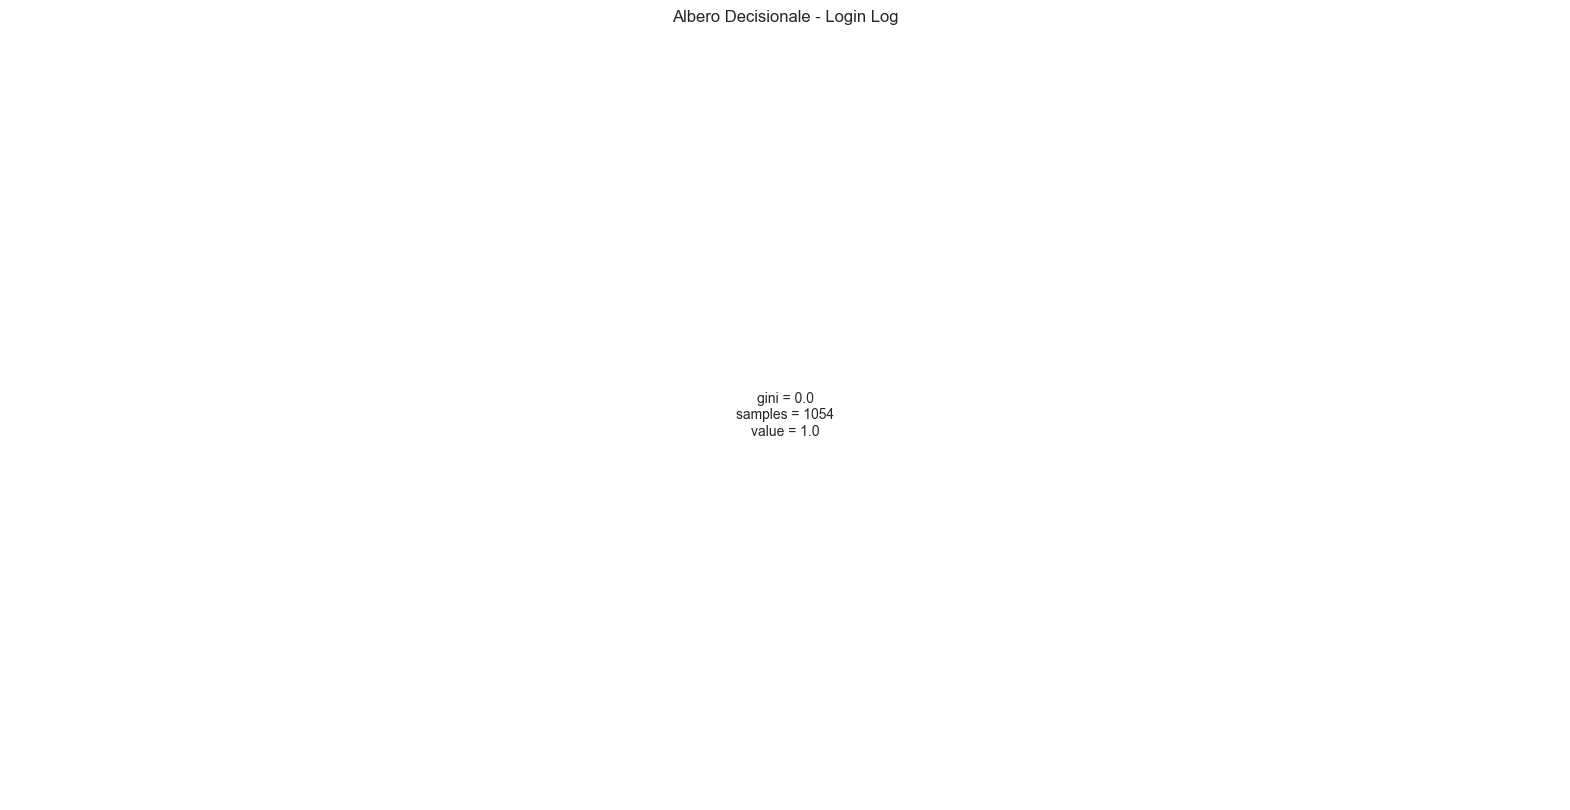

In [115]:
# Dibujamos el árbol completo para entender
# Disegniamo l'albero completo per capire
# qué decisiones toma el modelo y en qué variables se apoya.
# quali decisioni prende il modello e su quali variabili si basa.
plt.figure(figsize=(20, 10))
plot_tree(
    login_tree,
    feature_names=features_login,
    class_names=["Normale", "Anomalo"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Albero Decisionale - Login Log")
plt.show()

In [116]:
# export_text transforma el árbol a una representación textual.
# export_text trasforma l'albero in una rappresentazione testuale.
# Esto facilita incluir reglas del modelo en documentación o informes.
# Questo facilita l'inclusione delle regole del modello nella documentazione o nei report.
rules_login = export_text(login_tree, feature_names=features_login)
print(rules_login)

|--- class: 0



In [117]:
# =========================
# PREPARACIÓN MODELO ACTIVITY
# PREPARAZIONE MODELLO ACTIVITY
# =========================

# Copia del dataset ya enriquecido y etiquetado.
# Copia del dataset già arricchito ed etichettato.
activity_model_df = activity_df.copy()

# Selección de variables predictoras del modelo de actividad.
# Selezione delle variabili predittive del modello di attività.
# Aquí usamos información sobre usuario, elemento, entidad, acción y tiempo.
# Qui utilizziamo informazioni su utente, elemento, entità, azione e tempo.
features_activity = ["user_id", "element_id", "entity_id", "action_id", "hour", "minute", "day_of_week"]
target_activity = "anomaly"

# Variables de entrada y variable objetivo.
# Variabili di input e variabile target.
X_activity = activity_model_df[features_activity].copy()
y_activity = activity_model_df[target_activity].copy()

# División en entrenamiento y test.
# Suddivisione in training e test.
Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    X_activity, y_activity, test_size=0.2, random_state=42, stratify=y_activity
)

print("Training Activity:", Xa_train.shape)
print("Test Activity:", Xa_test.shape)

Training Activity: (2400, 7)
Test Activity: (600, 7)


In [118]:
# =========================
# MODELO ACTIVITY
# MODELLO ACTIVITY
# =========================

# Creamos el árbol de decisión para el dataset de actividad.
# Creiamo l'albero decisionale per il dataset di attività.
# En este caso se permite una profundidad algo mayor
# In questo caso si consente una profondità leggermente maggiore
# porque el problema tiene más variables y combinaciones.
# perché il problema ha più variabili e combinazioni.
activity_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Entrenamiento del modelo.
# Addestramento del modello.
activity_tree.fit(Xa_train, ya_train)

print("Modello di Activity addestrato correttamente.")

Modello di Activity addestrato correttamente.


In [119]:
# Predicción sobre el conjunto de prueba del Activity Log.
# Predizione sul set di test dell'Activity Log.
ya_pred = activity_tree.predict(Xa_test)

# Exactitud global.
# Accuratezza globale.
print("Accuracy Activity:", accuracy_score(ya_test, ya_pred))

# Métricas detalladas por clase.
# Metriche dettagliate per classe.
print("\nClassification Report - Activity")
print(classification_report(ya_test, ya_pred))

Accuracy Activity: 1.0

Classification Report - Activity
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       593
           1       1.00      1.00      1.00         7

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



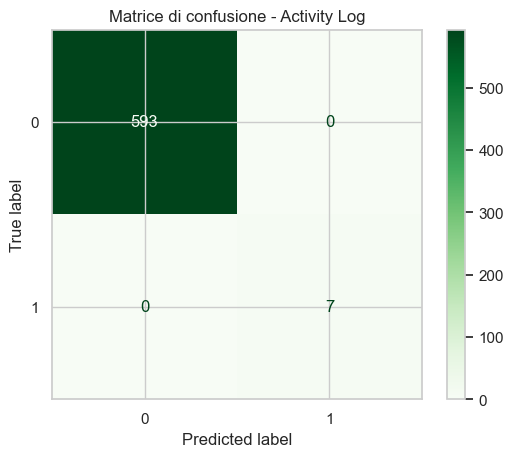

In [134]:
# Matriz de confusión del modelo de actividad.
# Matrice di confusione del modello di attività.
cm_activity = confusion_matrix(ya_test, ya_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_activity,
    display_labels=["0", "1"]
)

disp.plot(cmap="Greens")
plt.title("Matrice di confusione - Activity Log")
plt.show()

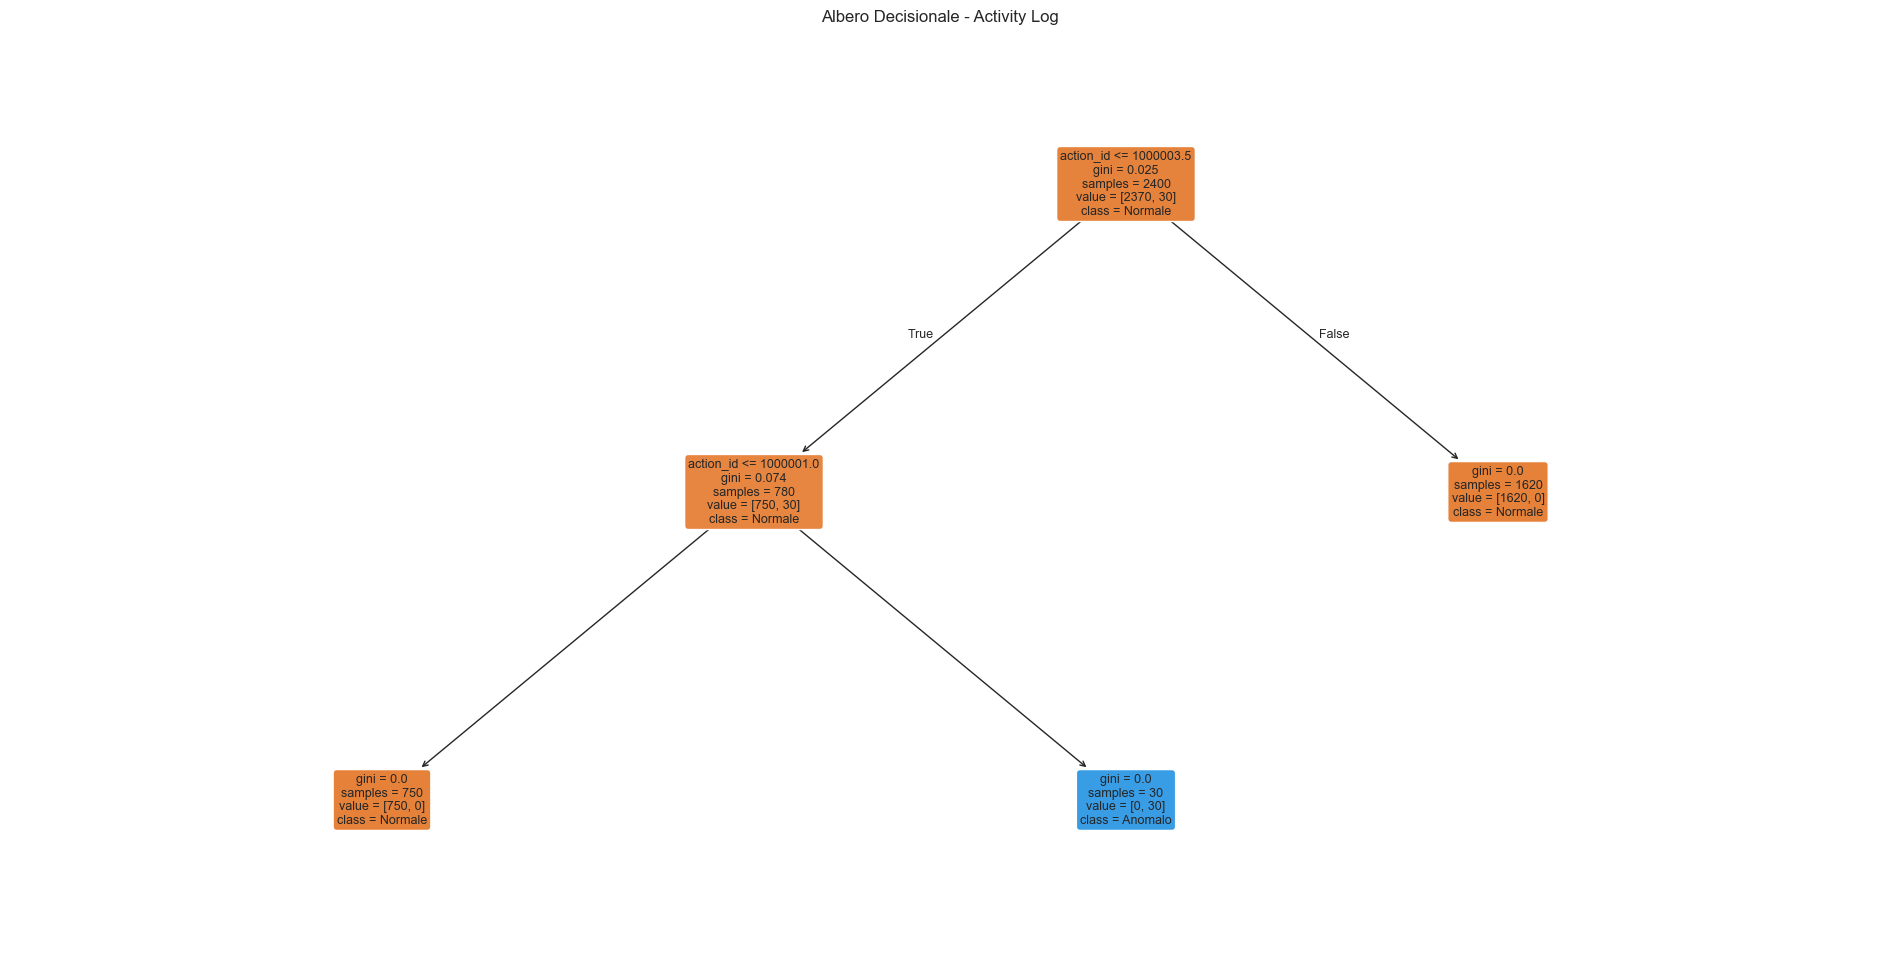

In [121]:
# Representación gráfica del árbol de actividad.
# Rappresentazione grafica dell'albero di attività.
# Muy útil en la defensa del proyecto porque permite
# Molto utile nella presentazione del progetto perché permette
# mostrar qué criterios separan actividad normal y anómala.
# di mostrare quali criteri separano l'attività normale da quella anomala.
plt.figure(figsize=(24, 12))
plot_tree(
    activity_tree,
    feature_names=features_activity,
    class_names=["Normale", "Anomalo"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Albero Decisionale - Activity Log")
plt.show()

In [122]:
# Convertimos el árbol de actividad en una representación textual.
# Convertiamo l'albero di attività in una rappresentazione testuale.
# Esto hace más fácil revisar y documentar las reglas de decisión.
# Questo rende più semplice rivedere e documentare le regole decisionali.
rules_activity = export_text(activity_tree, feature_names=features_activity)
print(rules_activity)

|--- action_id <= 1000003.50
|   |--- action_id <= 1000001.00
|   |   |--- class: 0
|   |--- action_id >  1000001.00
|   |   |--- class: 1
|--- action_id >  1000003.50
|   |--- class: 0



In [123]:
# Aplicamos ambos modelos sobre todos los registros para comparar
# Applichiamo entrambi i modelli su tutti i record per confrontare
# la etiqueta real generada por reglas con la predicción del árbol.
# l'etichetta reale generata dalle regole con la previsione dell'albero.
login_df["predicted_anomaly"] = login_tree.predict(X_login)
activity_df["predicted_anomaly"] = activity_tree.predict(X_activity)

# Mostramos una comparación entre la anomalía real y la predicha
# Mostriamo un confronto tra l'anomalia reale e quella predetta
# en el dataset de login.
# nel dataset di login.
print("LOGIN - confronto reale vs previsione")
display(login_df[["login_log_id", "user_id", "user_name", "logged_at", "anomaly", "predicted_anomaly"]].head(20))

# Hacemos lo mismo con el dataset de actividad.
# Facciamo lo stesso con il dataset di attività.
print("\nACTIVITY - confronto reale vs previsione")
display(activity_df[["activity_log_id", "user_id", "user_name", "element_id", "action_id", "logged_at", "anomaly", "predicted_anomaly"]].head(20))

LOGIN - confronto reale vs previsione


,login_log_id,user_id,user_name,logged_at,anomaly,predicted_anomaly
0,3,1,Matteo Nicolosi,2026-01-01 09:06:55.942,0,0
1,4,2,Diego Scardino,2026-01-01 12:23:22.204,0,0
2,6,3,Emilio Sardo,2026-01-01 17:40:17.890,0,0
3,9,1,Matteo Nicolosi,2026-01-02 10:10:32.177,0,0
4,10,2,Diego Scardino,2026-01-02 12:47:29.386,0,0
5,12,3,Emilio Sardo,2026-01-02 16:12:38.083,0,0
6,13,1,Matteo Nicolosi,2026-01-05 09:20:03.990,0,0
7,16,2,Diego Scardino,2026-01-05 13:49:11.388,0,0
8,17,3,Emilio Sardo,2026-01-05 16:22:10.634,0,0
9,18,1,Matteo Nicolosi,2026-01-06 09:20:18.448,0,0



ACTIVITY - confronto reale vs previsione


,activity_log_id,user_id,user_name,element_id,action_id,logged_at,anomaly,predicted_anomaly
0,1,1,Matteo Nicolosi,2,1000000,2026-01-01 10:31:04.217,0,0
1,2,2,Diego Scardino,3,1000004,2026-01-01 14:37:47.860,0,0
2,3,3,Emilio Sardo,6,1000005,2026-01-01 17:44:36.455,0,0
3,4,1,Matteo Nicolosi,1,1000000,2026-01-02 10:14:36.855,0,0
4,5,1,Matteo Nicolosi,2,1000000,2026-01-02 10:15:31.904,0,0
5,6,1,Matteo Nicolosi,2,1000004,2026-01-02 10:34:10.221,0,0
6,7,1,Matteo Nicolosi,1,1000005,2026-01-02 10:45:38.782,0,0
7,8,1,Matteo Nicolosi,1,1000004,2026-01-02 10:50:27.144,0,0
8,9,1,Matteo Nicolosi,2,1000005,2026-01-02 11:00:25.523,0,0
9,10,1,Matteo Nicolosi,1,1000005,2026-01-02 11:17:42.260,0,0


In [124]:
# Filtramos únicamente los registros que el modelo clasifica como anómalos.
# Filtriamo unicamente i record che il modello classifica come anomali.
login_anomalies = login_df[login_df["predicted_anomaly"] == 1].copy()

print("Casi anomali rilevati nel Login:")
display(
    login_anomalies[
        ["login_log_id", "user_id", "user_name", "result", "attempt", "logged_at", "logout_at", "hour"]
    ].sort_values("logged_at")
)

Casi anomali rilevati nel Login:


,login_log_id,user_id,user_name,result,attempt,logged_at,logout_at,hour


In [125]:
# Filtramos las actividades marcadas como anómalas por el modelo.
# Filtriamo le attività contrassegnate come anomale dal modello.
activity_anomalies = activity_df[activity_df["predicted_anomaly"] == 1].copy()

print("Casi anomali rilevati in Activity:")
display(
    activity_anomalies[
        ["activity_log_id", "user_id", "user_name", "element_id", "entity_id", "action_id", "action_name", "logged_at", "hour"]
    ].sort_values("logged_at")
)

Casi anomali rilevati in Activity:


,activity_log_id,user_id,user_name,element_id,entity_id,action_id,action_name,logged_at,hour
18,19,2,Diego Scardino,3,1,1000002,Edit,2026-01-05 14:37:16.392,14
24,25,2,Diego Scardino,3,1,1000003,Delete,2026-01-05 14:50:48.057,14
30,31,1,Matteo Nicolosi,2,1,1000002,Edit,2026-01-06 10:15:45.588,10
33,34,1,Matteo Nicolosi,1,1,1000002,Edit,2026-01-07 11:40:30.066,11
35,36,2,Diego Scardino,3,1,1000002,Edit,2026-01-07 14:19:58.581,14
41,42,2,Diego Scardino,3,1,1000002,Edit,2026-01-07 14:26:30.722,14
50,51,2,Diego Scardino,3,1,1000002,Edit,2026-01-09 14:32:10.272,14
74,75,1,Matteo Nicolosi,1,1,1000002,Edit,2026-01-15 11:24:50.724,11
79,80,1,Matteo Nicolosi,2,1,1000002,Edit,2026-01-15 11:39:54.764,11
84,85,2,Diego Scardino,3,1,1000002,Edit,2026-01-16 14:25:03.040,14


In [126]:
# Definimos una función que permite probar manualmente
# Definiamo una funzione che permette di testare manualmente
# nuevos casos de login sin tener que rehacer todo el pipeline.
# nuovi casi di login senza dover rifare tutta la pipeline.
def predict_login_anomaly(user_id, result, attempt, logged_at, logout_at):
    # Convertimos las fechas introducidas a datetime.
    # Convertiamo le date inserite in datetime.
    logged_at = pd.to_datetime(logged_at)
    logout_at = pd.to_datetime(logout_at)

    # Construimos un DataFrame con la misma estructura
    # Costruiamo un DataFrame con la stessa struttura
    # de variables que espera el modelo.
    # di variabili che il modello si aspetta.
    row = pd.DataFrame([{
        "user_id": user_id,
        "result": int(result),
        "attempt": attempt,
        "hour": logged_at.hour,
        "minute": logged_at.minute,
        "day_of_week": logged_at.dayofweek,
        "session_duration_min": (logout_at - logged_at).total_seconds() / 60
    }])

    # Obtenemos la predicción y las probabilidades.
    # Otteniamo la previsione e le probabilità.
    pred = login_tree.predict(row)[0]
    prob = login_tree.predict_proba(row)[0]

    # Mostramos resultado.
    # Mostriamo il risultato.
    print("Previsione:", "ANOMALO" if pred == 1 else "NORMALE")
    print("Probabilità [Normale, Anomalo]:", prob)

# Ejemplo de uso:
# Esempio di utilizzo:
predict_login_anomaly(
    user_id=1,
    result=True,
    attempt=2,
    logged_at="2026-01-15 16:30:00",
    logout_at="2026-01-15 17:00:00"
)

Previsione: NORMALE
Probabilità [Normale, Anomalo]: [1.]


In [127]:
# Función equivalente para probar nuevos eventos del Activity Log.
# Funzione equivalente per testare nuovi eventi dell'Activity Log.
def predict_activity_anomaly(user_id, element_id, entity_id, action_id, logged_at):
    # Convertimos la fecha a datetime.
    # Convertiamo la data in datetime.
    logged_at = pd.to_datetime(logged_at)

    # Construimos el registro de entrada con el formato
    # Costruiamo il record di input con il formato
    # que necesita el modelo de actividad.
    # di cui ha bisogno il modello di attività.
    row = pd.DataFrame([{
        "user_id": user_id,
        "element_id": element_id,
        "entity_id": entity_id,
        "action_id": action_id,
        "hour": logged_at.hour,
        "minute": logged_at.minute,
        "day_of_week": logged_at.dayofweek
    }])

    # Predicción y probabilidades.
    # Previsione e probabilità.
    pred = activity_tree.predict(row)[0]
    prob = activity_tree.predict_proba(row)[0]

    # Mostramos resultado.
    # Mostriamo il risultato.
    print("Previsione:", "ANOMALO" if pred == 1 else "NORMALE")
    print("Probabilità [Normale, Anomalo]:", prob)

# Ejemplo de uso:
# Esempio di utilizzo:
predict_activity_anomaly(
    user_id=2,
    element_id=1,
    entity_id=1,
    action_id=1000005,
    logged_at="2026-01-20 13:15:00"
)

Previsione: NORMALE
Probabilità [Normale, Anomalo]: [1. 0.]


In [128]:
# =========================
# ENTRENAMIENTO DEL MODELO RANDOM FOREST
# ADDESTRAMENTO DEL MODELLO RANDOM FOREST
# =========================

# Creamos el modelo Random Forest.
# Creiamo il modello Random Forest.
# Parámetros elegidos:
# Parametri scelti:
# - n_estimators: número de árboles que formarán el bosque.
# - n_estimators: numero di alberi che formeranno la foresta.
# - max_depth: profundidad máxima de cada árbol, para evitar sobreajuste excesivo.
# - max_depth: profondità massima di ogni albero, per evitare un overfitting eccessivo.
# - min_samples_split: mínimo de muestras para dividir un nodo.
# - min_samples_split: numero minimo di campioni per dividere un nodo.
# - min_samples_leaf: mínimo de muestras que debe tener una hoja.
# - min_samples_leaf: numero minimo di campioni che deve avere una foglia.
# - random_state: garantiza reproducibilidad.
# - random_state: garantisce la riproducibilità.
# - n_jobs=-1: usa todos los núcleos del procesador disponibles.
# - n_jobs=-1: utilizza tutti i core del processore disponibili.
rf_activity = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Entrenamos el modelo con los datos de entrenamiento.
# Addestriamo il modello con i dati di training.
rf_activity.fit(Xa_train, ya_train)

# Mostramos confirmación y accuracy en train/test
# Mostriamo una conferma e l'accuracy su train/test
# para tener una primera visión de si hay sobreajuste.
# per avere una prima idea dell'eventuale presenza di overfitting.
print("Modello Random Forest addestrato correttamente.")
print("Accuracy train:", rf_activity.score(Xa_train, ya_train))
print("Accuracy test:", rf_activity.score(Xa_test, ya_test))

Modello Random Forest addestrato correttamente.
Accuracy train: 0.9995833333333334
Accuracy test: 0.9983333333333333


In [129]:
# =========================
# EVALUACIÓN DEL MODELO RANDOM FOREST
# VALUTAZIONE DEL MODELLO RANDOM FOREST
# =========================

# Generamos predicciones sobre el conjunto de prueba.
# Generiamo predizioni sul set di test.
ya_pred_rf = rf_activity.predict(Xa_test)

# Accuracy global del modelo.
# Accuracy globale del modello.
print("Accuracy Random Forest:", accuracy_score(ya_test, ya_pred_rf))

# El classification report muestra métricas más completas:
# Il classification report mostra metriche più complete:
# - precision
# - precision
# - recall
# - recall
# - f1-score
# - f1-score
# Esto es especialmente importante en problemas de detección de anomalías.
# Questo è particolarmente importante nei problemi di rilevamento delle anomalie.
print("\nClassification Report - Random Forest (Activity Log)")
print(
    classification_report(
        ya_test,
        ya_pred_rf,
        labels=[0, 1],
        target_names=["Normale", "Anomalo"],
        zero_division=0
    )
)

Accuracy Random Forest: 0.9983333333333333

Classification Report - Random Forest (Activity Log)
              precision    recall  f1-score   support

     Normale       1.00      1.00      1.00       593
     Anomalo       1.00      0.86      0.92         7

    accuracy                           1.00       600
   macro avg       1.00      0.93      0.96       600
weighted avg       1.00      1.00      1.00       600



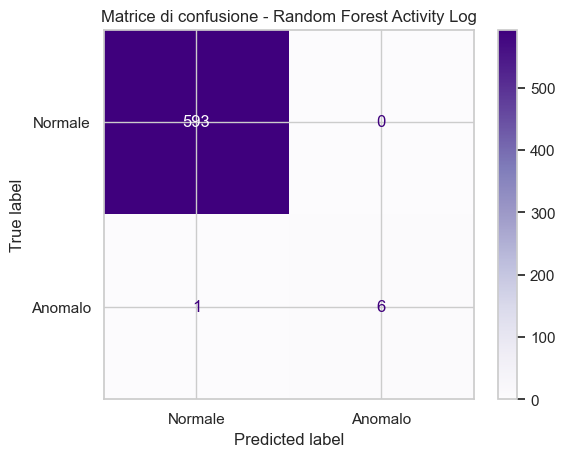

In [130]:
# =========================
# MATRIZ DE CONFUSIÓN - RANDOM FOREST
# MATRICE DI CONFUSIONE - RANDOM FOREST
# =========================

# Calculamos la matriz de confusión forzando las clases [0, 1]
# Calcoliamo la matrice di confusione forzando le classi [0, 1]
# para que siempre se represente correctamente.
# affinché venga sempre rappresentata correttamente.
cm_rf = confusion_matrix(ya_test, ya_pred_rf, labels=[0, 1])

# Mostramos la matriz con etiquetas claras.
# Mostriamo la matrice con etichette chiare.
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Normale", "Anomalo"]
)

disp.plot(cmap="Purples")
plt.title("Matrice di confusione - Random Forest Activity Log")
plt.show()

In [131]:
# =========================
# IMPORTANCIA DE VARIABLES - RANDOM FOREST
# IMPORTANZA DELLE VARIABILI - RANDOM FOREST
# =========================

# Extraemos la importancia de cada variable utilizada por el modelo.
# Estraiamo l'importanza di ogni variabile utilizzata dal modello.
rf_importance_df = pd.DataFrame({
    "feature": X_activity.columns,
    "importance": rf_activity.feature_importances_
}).sort_values("importance", ascending=False)

# Mostramos la tabla ordenada de mayor a menor importancia.
# Mostriamo la tabella ordinata dalla variabile più importante alla meno importante.
display(rf_importance_df)

,feature,importance
3,action_id,0.779787
5,minute,0.129861
6,day_of_week,0.038455
4,hour,0.026040
1,element_id,0.017815
0,user_id,0.008042
2,entity_id,0.000000


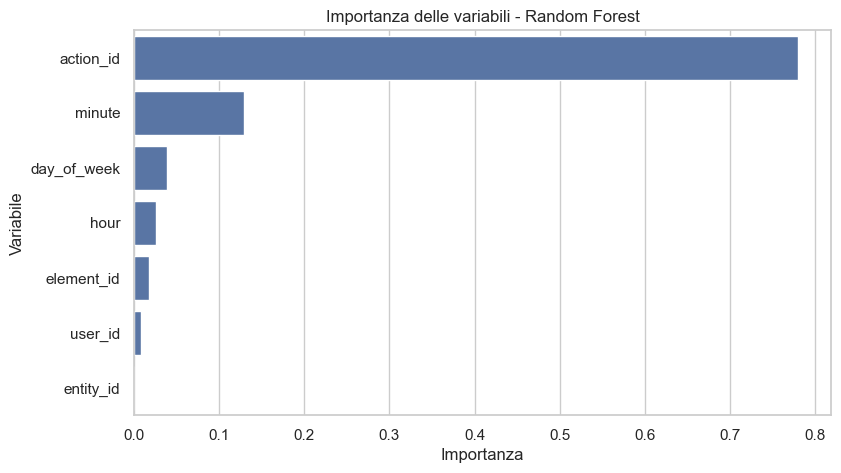

In [132]:
# =========================
# GRÁFICA DE IMPORTANCIA DE VARIABLES
# GRAFICO DELL'IMPORTANZA DELLE VARIABILI
# =========================

plt.figure(figsize=(9, 5))
sns.barplot(data=rf_importance_df, x="importance", y="feature")
plt.title("Importanza delle variabili - Random Forest")
plt.xlabel("Importanza")
plt.ylabel("Variabile")
plt.show()

In [133]:
# =========================
# COMPARACIÓN ENTRE DECISION TREE Y RANDOM FOREST
# CONFRONTO TRA DECISION TREE E RANDOM FOREST
# =========================

print("DECISION TREE")
print("Accuracy test:", accuracy_score(ya_test, ya_pred))

print("\nRANDOM FOREST")
print("Accuracy test:", accuracy_score(ya_test, ya_pred_rf))

DECISION TREE
Accuracy test: 1.0

RANDOM FOREST
Accuracy test: 0.9983333333333333


# CONCLUSIONES FINALES

A lo largo de este proyecto se han cargado, analizado y preparado dos fuentes principales de datos, **Login Log** y **Activity Log**, con el objetivo de construir una primera **PoC de detección de anomalías** en el comportamiento de los usuarios. Para ello, se han transformado las variables temporales más relevantes, generando información útil como la **hora**, el **minuto**, el **día de la semana** y la **duración de la sesión**, lo que ha permitido enriquecer el análisis y preparar correctamente los datos para el modelado.

A partir de las reglas de negocio definidas, se han implementado criterios de detección para identificar comportamientos anómalos, tales como **logins fuera de la franja horaria habitual del usuario**, accesos realizados **fuera de los días laborables**, actividades ejecutadas **fuera del horario permitido**, accesos a **elementos no autorizados**, acciones sobre **entity distinta de password** y eventos realizados **fuera del flujo estándar esperado**. De esta manera, se ha construido una base sólida para etiquetar anomalías de forma coherente con el contexto funcional del sistema.

Sobre esta base, se han entrenado modelos de **Árbol de Decisión** para los datos de login y de actividad, ya que se trata de un enfoque especialmente adecuado para una primera PoC gracias a su **alta interpretabilidad**, su capacidad para **explicar la lógica de clasificación** y su utilidad para presentar resultados de forma clara y defendible ante negocio. Como mejora adicional, se ha incorporado también **Random Forest**, con el fin de reforzar la robustez del sistema. Este modelo ha permitido aportar **mayor estabilidad frente a variaciones del dataset**, **reducir el riesgo de sobreajuste**, **mejorar la capacidad de generalización** en datos no vistos y analizar la relevancia de las variables mediante sus importancias.

En conjunto, puede concluirse que el **Árbol de Decisión** representa el modelo más adecuado para explicar el comportamiento del sistema y la lógica de negocio, mientras que **Random Forest** constituye una evolución natural del mismo cuando se busca una solución más robusta y orientada a un futuro escenario de producción. Por tanto, el enfoque desarrollado resulta apropiado para una primera fase del proyecto, al combinar **reglas de negocio**, **modelos interpretables** y una primera mejora orientada a la **robustez predictiva**.

Como líneas de mejora futura, sería recomendable **ampliar el número de usuarios y casuísticas reales**, incorporar **secuencias completas de comportamiento** como `login -> actividad -> logout`, introducir **features agregadas por usuario y por día** y evolucionar hacia un **sistema en tiempo real** capaz de bloquear o revisar acciones sospechosas automáticamente. Todo ello permitiría aumentar progresivamente la precisión y utilidad operativa del sistema en un entorno real.

---

# CONCLUSIONI FINALI

Nel corso di questo progetto sono state caricate, analizzate e preparate due principali fonti di dati, **Login Log** e **Activity Log**, con l’obiettivo di costruire una prima **PoC per il rilevamento delle anomalie** nel comportamento degli utenti. A tal fine, sono state trasformate le variabili temporali più rilevanti, generando informazioni utili come **ora**, **minuto**, **giorno della settimana** e **durata della sessione**, così da arricchire l’analisi e preparare correttamente i dati per il modellamento.

A partire dalle regole di business definite, sono stati implementati criteri di rilevamento per identificare comportamenti anomali, come **login fuori dalla fascia oraria abituale dell’utente**, accessi effettuati **al di fuori dei giorni lavorativi**, attività eseguite **fuori dall’orario consentito**, accessi a **elementi non autorizzati**, azioni su **entity diversa da password** ed eventi effettuati **al di fuori del flusso standard previsto**. In questo modo è stata costruita una base solida per etichettare le anomalie in modo coerente con il contesto funzionale del sistema.

Su questa base, sono stati addestrati modelli di **Albero di Decisione** per i dati di login e di activity, poiché si tratta di un approccio particolarmente adatto a una prima PoC grazie alla sua **elevata interpretabilità**, alla capacità di **spiegare chiaramente la logica di classificazione** e alla sua utilità nel presentare risultati in modo comprensibile e difendibile dal punto di vista del business. Come miglioramento aggiuntivo, è stato inoltre introdotto **Random Forest**, con l’obiettivo di rafforzare la robustezza del sistema. Questo modello ha permesso di ottenere **maggiore stabilità rispetto alle variazioni del dataset**, **minore rischio di overfitting**, **migliore capacità di generalizzazione** su dati non visti e la possibilità di analizzare la rilevanza delle variabili attraverso le rispettive importanze.

Nel complesso, si può concludere che l’**Albero di Decisione** rappresenta il modello più adatto per spiegare il comportamento del sistema e la logica di business, mentre **Random Forest** costituisce una sua naturale evoluzione quando si desidera una soluzione più robusta e orientata a un futuro scenario di produzione. Di conseguenza, l’approccio sviluppato risulta appropriato per una prima fase del progetto, in quanto combina **regole di business**, **modelli interpretabili** e un primo miglioramento orientato alla **robustezza predittiva**.

Come possibili sviluppi futuri, sarebbe consigliabile **ampliare il numero di utenti e di casistiche reali**, includere **sequenze complete di comportamento** come `login -> attività -> logout`, introdurre **feature aggregate per utente e per giorno** ed evolvere verso un **sistema in tempo reale** capace di bloccare o sottoporre a revisione automatica le azioni sospette. Tutto ciò permetterebbe di aumentare progressivamente la precisione e l’utilità operativa del sistema in un contesto reale.

Prossimo passi
- instalare dbver✅
- POstgres✅
- importazione dell db
- popolamento db con dati anomalie piu login (100000 login e 100000 activiti)
- Processo python per collegare il modelo al db e rendere il modelo aggionarto a i dati presenti sull db
- Creare una aplicazione dove io accedo e lui mi dice si posso accedere oppure no e anche i activiti, super simple que sea incluso en linea de comandos q no hay q complicarse. 
- actualizar el modelo para que sea mas realista en cuanto movimientos, tipo que diego o matteo pueda hacer edit, eliminar o mas acciones y que sea mas realista
- explicar mas especifico los datos que se han hecho durante el analisis

